# 1. Exploratory Data Analysis (EDA)

Mục tiêu của notebook này là thực hiện kiểm tra và hình dung tập dữ liệu hành vi người dùng (eCommerce behavior data). Cụ thể chúng ta sẽ kiểm tra:
1. Cấu trúc cột và kiểu dữ liệu có bị null không.
2. Tần suất của các loai `event_type` để xem xét việc gán pseudo-labels.
3. Check tính thưa thớt (sparsity) của tập dữ liệu.
4. Các nhóm sản phẩm (categories) thịnh hành phổ biến nhất.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Cấu hình hiển thị biểu đồ
%matplotlib inline
sns.set_style('whitegrid')
import warnings
warnings.filterwarnings('ignore')

In [2]:
# Khai báo đường dẫn đến file raw
data_path = '../data/raw/2019-Oct.csv'

# Lưu ý: File này nặng ~5.7GB chứa hơn 42 triệu dòng.
# Để EDA mượt mà không crash RAM máy cá nhân, tải trước 1-2 triệu dòng để quan sát phân bố.
df = pd.read_csv(data_path, nrows=2000000)

print(f"Data shape: {df.shape}")
df.head()

Data shape: (2000000, 9)


,event_time,event_type,product_id,category_id,category_code,brand,price,user_id,user_session
0,2019-10-01 00:00:00 UTC,view,44600062,2103807459595387724,NaN,shiseido,35.79,541312140,72d76fde-8bb3-4e00-8c23-a032dfed738c
1,2019-10-01 00:00:00 UTC,view,3900821,2053013552326770905,appliances.environment.water_heater,aqua,33.20,554748717,9333dfbd-b87a-4708-9857-6336556b0fcc
2,2019-10-01 00:00:01 UTC,view,17200506,2053013559792632471,furniture.living_room.sofa,NaN,543.10,519107250,566511c2-e2e3-422b-b695-cf8e6e792ca8
3,2019-10-01 00:00:01 UTC,view,1307067,2053013558920217191,computers.notebook,lenovo,251.74,550050854,7c90fc70-0e80-4590-96f3-13c02c18c713
4,2019-10-01 00:00:04 UTC,view,1004237,2053013555631882655,electronics.smartphone,apple,1081.98,535871217,c6bd7419-2748-4c56-95b4-8cec9ff8b80d


### Kiểm tra thông tin cột và Missing Value

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 9 columns):
 #   Column         Dtype  
---  ------         -----  
 0   event_time     str    
 1   event_type     str    
 2   product_id     int64  
 3   category_id    int64  
 4   category_code  str    
 5   brand          str    
 6   price          float64
 7   user_id        int64  
 8   user_session   str    
dtypes: float64(1), int64(3), str(5)
memory usage: 137.3 MB


In [8]:
df.isnull().sum() / len(df) * 100

event_time        0.0000
event_type        0.0000
product_id        0.0000
category_id       0.0000
category_code    31.8224
brand            14.8761
price             0.0000
user_id           0.0000
user_session      0.0000
dtype: float64

### Phân tích sự kiện hành vi `event_type`

event_type
view        1936686
purchase      33877
cart          29437
Name: count, dtype: int64


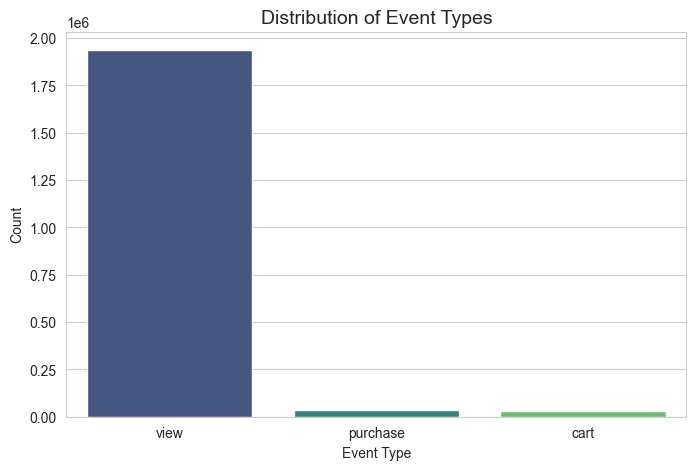

In [9]:
event_counts = df['event_type'].value_counts()
print(event_counts)

plt.figure(figsize=(8, 5))
sns.barplot(x=event_counts.index, y=event_counts.values, palette='viridis')
plt.title('Distribution of Event Types', fontsize=14)
plt.ylabel('Count')
plt.xlabel('Event Type')
plt.show()

### Kiểm tra độ thưa thớt (Sparsity) của ma trận User-Item

In [10]:
num_users = df['user_id'].nunique()
num_items = df['product_id'].nunique()
num_interactions = len(df)

sparsity = 1.0 - (num_interactions / (num_users * num_items))

print(f"Total Unique Users: {num_users:,}")
print(f"Total Unique Items: {num_items:,}")
print(f"Total Interactions: {num_interactions:,}")
print(f"Sparsity: {sparsity:.6f}")
print("\n=> Độ thưa thớt ~99.9% là chuyện cực kỳ bình thường trong Recommender Systems thực tế.")

Total Unique Users: 295,883
Total Unique Items: 81,476
Total Interactions: 2,000,000
Sparsity: 0.999917

=> Độ thưa thớt ~99.9% là chuyện cực kỳ bình thường trong Recommender Systems thực tế.


### Phân tích Mức giá (Price Distribution)

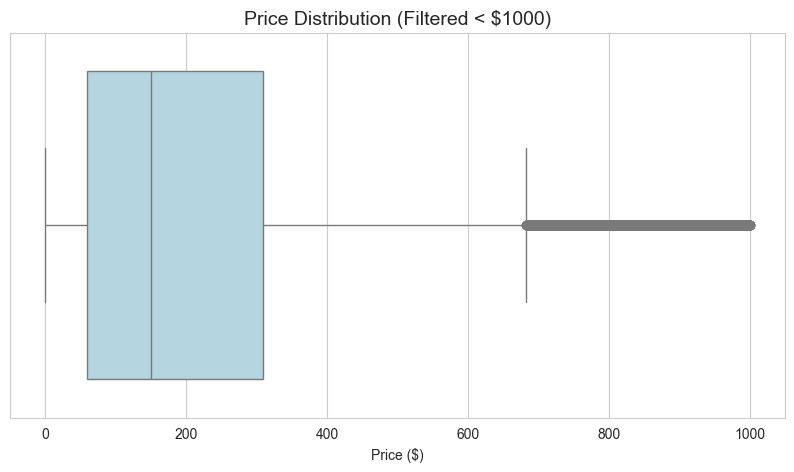

count    2.000000e+06
mean     2.969424e+02
std      3.700994e+02
min      0.000000e+00
25%      6.408000e+01
50%      1.619100e+02
75%      3.627700e+02
max      2.574070e+03
Name: price, dtype: float64

In [11]:
plt.figure(figsize=(10, 5))
# Loại bỏ các outliers giá quá cao để vẽ boxplot
sns.boxplot(x=df[df['price'] < 1000]['price'], color='lightblue')
plt.title('Price Distribution (Filtered < $1000)', fontsize=14)
plt.xlabel('Price ($)')
plt.show()

df['price'].describe()